In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sbnd_style
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import norm, multivariate_normal

In [24]:
def make_legend(ax, loc=(0.65, 0.6)):
    return ax.legend(frameon=False, loc="upper left",
                     bbox_to_anchor=loc, fontsize=20)

In [25]:
def one_d_hist_example():
    fig, ax = plt.subplots()
    mc = np.random.normal(0, 1, 1000)
    data = np.random.normal(0, 1, 1000)
    bins = np.linspace(-5, 5, 21)

    h_mc, b_mc, mc_lines = ax.hist(mc, bins=bins, histtype="step", label="MC", lw=2, color=sbnd_style.OKABE_ITO_COLORS['blue'])
    bin_centers_mc = 0.5*(b_mc[1:] + b_mc[:-1])
    mc_error = np.sqrt(h_mc) 
    ax.fill_between( bin_centers_mc, h_mc - mc_error, h_mc + mc_error, step='mid', alpha=1, hatch='///', label='Syst. unc.', edgecolor='gray', facecolor='none' , lw=0)
    mc_line = Line2D( [0], [0], color=mc_lines[0].get_edgecolor(), lw=2.5 )
    mc_fill = Patch( facecolor='none', edgecolor='gray', hatch='///' )

    h_data, bin_edges = np.histogram(data, bins=bins)
    data_error = np.sqrt(h_data)
    centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    centers_width = 0.5*(bin_edges[1:] - bin_edges[:-1])
    data_handle = ax.errorbar(centers, h_data, xerr=centers_width, yerr=data_error, fmt="o", label="Data")

    ax.set_xlabel("x label")
    ax.set_ylabel("y label")
    ax.legend(handles=[(mc_fill, mc_line),data_handle], labels=["MC","Data"], handler_map={tuple: plt.matplotlib.legend_handler.HandlerTuple()}, loc="upper left", bbox_to_anchor=(0.65, 0.6))
    ax.set_ylim(0, max(max(h_mc + mc_error), max(h_data + data_error))*1.15)

    sbnd_style.center_titles(ax) 
    sbnd_style.sbnd_wip(ax, 0.02, 0.98, fontsize=30)



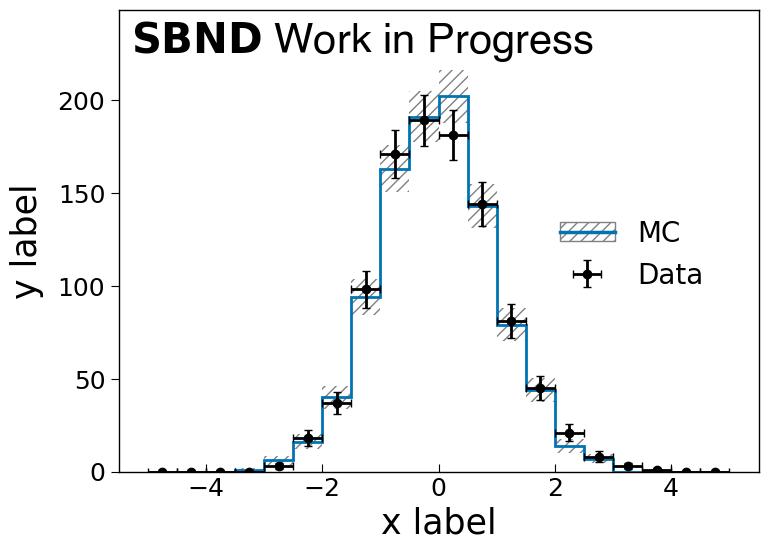

In [26]:
one_d_hist_example()

In [42]:
def datamc_example():
    fig = plt.figure(figsize=(8,8))
    ax1, ax2 = sbnd_style.split_canvas(fig)

    data = np.random.normal(0, 1, 1000)
    bins = np.linspace(-5, 5, 51)

    counts, edges = np.histogram(data, bins=bins)
    centers = 0.5*(edges[1:] + edges[:-1])

    # Fit
    mu, sigma = norm.fit(data)
    fit_y = norm.pdf(centers, mu, sigma)
    fit_y *= counts.sum() * (edges[1] - edges[0])

    ax1.errorbar(centers, counts, yerr=np.sqrt(counts), fmt="o", label="Data")
    ax1.plot(centers, fit_y, label="Fit")
    ax1.set_ylabel("y label")
    ax1.set_ylim(0, max(counts)*1.3)
    sbnd_style.center_titles(ax1)
    make_legend(ax1)

    sbnd_style.sbnd_preliminary(ax1, 0.02, 0.98)

    # Ratio
    ratio = (counts - fit_y) / fit_y
    ax2.axhline(0)
    ax2.errorbar( centers, ratio, yerr=np.sqrt(counts)/fit_y, fmt="o" )

    ax2.set_xlabel("x label")
    ax2.set_ylabel("(Data-Fit)/Fit")
    ax2.set_ylim(-.99, .99)

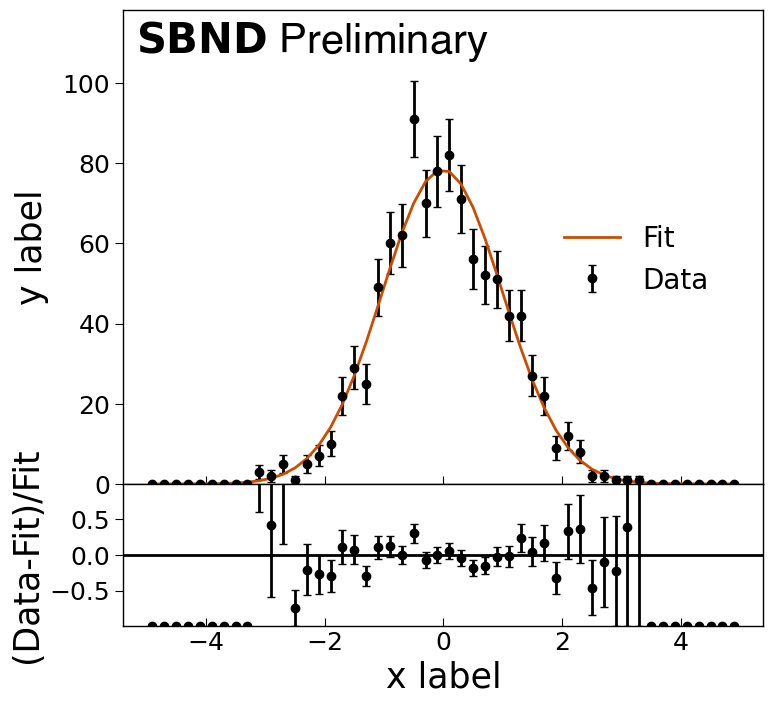

In [43]:
datamc_example()

In [29]:
def two_d_example():
    sbnd_style.apply_sea_palette()
    fig, ax = plt.subplots()

    mean = [0.5, -0.5]
    cov = [[1.0, 0.5], [0.5, 1.0]]
    data = np.random.multivariate_normal(mean, cov, 1_000_000)
    h = ax.hist2d( data[:, 0], data[:, 1], bins=[100, 120])
    levels = [0.682,  0.954, 0.997 ]
    labels = ["68%", "95%" , "99.7%" ]
    linestyles = [ "dashed", "dotted" , "solid" ]
    X, Y = np.meshgrid( np.linspace(-5, 5, 200), np.linspace(-5, 7, 200) )
    pos = np.dstack((X, Y))
    pdf = multivariate_normal(mean, cov).pdf(pos)
    colors = [sbnd_style.next_color() for _ in levels]
    cs = ax.contour(X, Y, pdf, levels=np.sort(pdf.max()*np.array(levels)), linestyles=linestyles, colors=colors)
    handles = [Line2D([0], [0], lw=2, linestyle=ls, color=c, label=lab) for lab, ls, c in zip(labels, linestyles, colors)]
    ax.legend(handles=handles, frameon=False)
    ax.set_xlabel("x label")
    ax.set_ylabel("y label")
    
    sbnd_style.sbnd_official(ax, 0.02, 0.95)
    sbnd_style.center_titles(ax)



<Figure size 800x600 with 0 Axes>

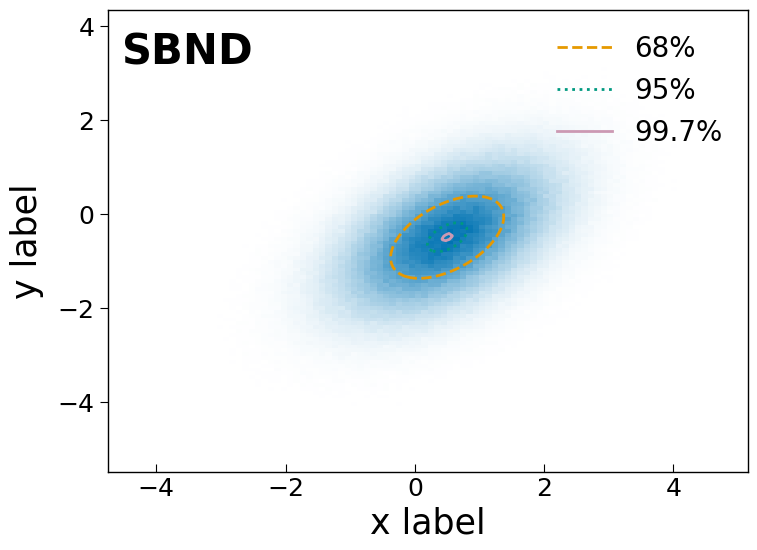

In [30]:
two_d_example()

In [31]:
def cov_example():
    sbnd_style.apply_symmetric_palette()

    fig, ax = plt.subplots()

    dim = 10
    cov = np.eye(dim)
    rng = np.random.default_rng(0)

    for i in range(dim):
        for j in range(i+1, dim):
            cov[i, j] = cov[j, i] = np.clip(rng.normal(0, 0.2), -1, 1)

    im = ax.imshow(cov, vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax)

    ax.set_xlabel("index i")
    ax.set_ylabel("index j")
    sbnd_style.center_titles(ax)
    sbnd_style.sbnd_preliminary(ax, 0.02, 1.1)



<Figure size 800x600 with 0 Axes>

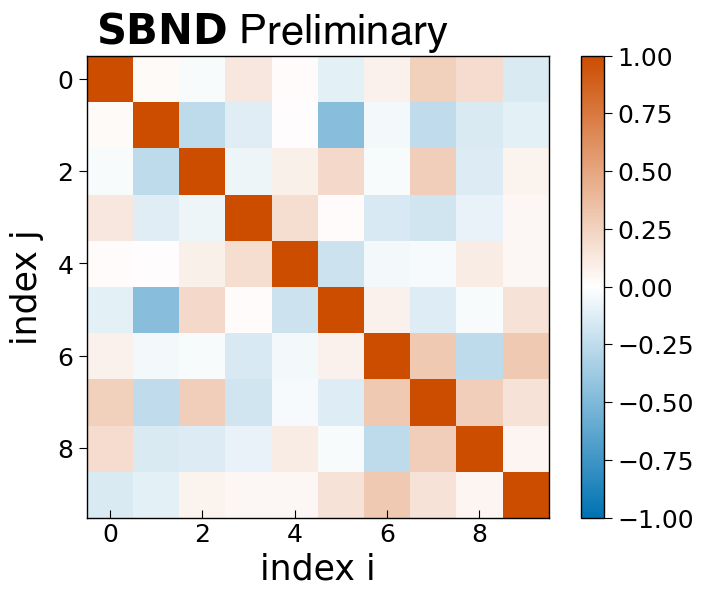

In [32]:
cov_example()

In [33]:
def stacked_example():
    nhists=8
    hists = []
    for i in range(nhists):
        mu = 2*i - (nhists - 1)
        data = np.random.normal(mu, 1.0, 1000*(i+1))
        hists.append(data)

    fig, ax = plt.subplots()
    bins = np.linspace(-10, 10, 100)
    h,b,f = ax.hist( hists, bins=bins, stacked=True, label=[f"Hist #{i+1}" for i in range(len(hists))])

    ax.set_xlabel("label x")
    ax.set_ylabel("label y")
    ax.set_xlim(min(bins), 1.8*max(bins))
    ax.set_ylim(min(np.concatenate(h)), 1.15*max(np.concatenate(h)))
    
    make_legend(ax, loc=(0.65, 0.9))
    sbnd_style.center_titles(ax)
    sbnd_style.sbnd_wip(ax, 0.02, 0.99)




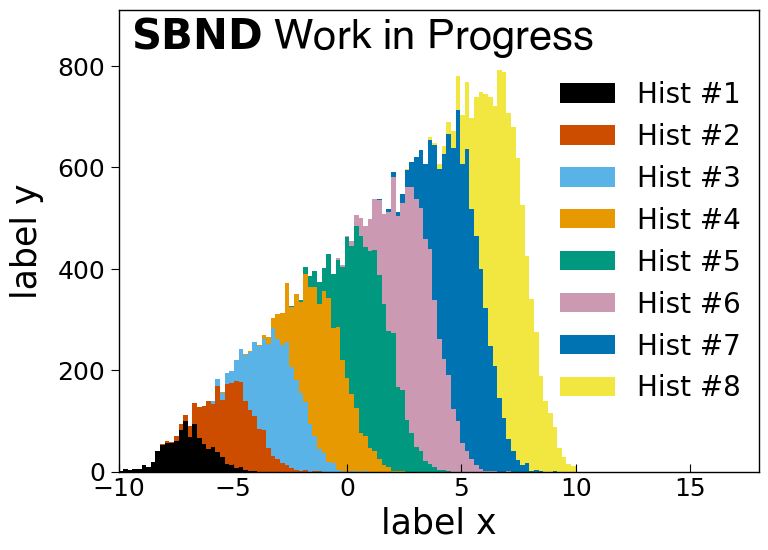

In [34]:
stacked_example()